# Import Packages

In [9]:
#!pip install numpy
#!pip install opencv-contrib-python
#!pip install tensorflow
#!pip install tqdm
#!pip install matplotlib
#!pip install seaborn
#!pip install pandas
#!pip install scikit-learn

In [8]:
import numpy as np
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tqdm import tqdm
import pandas as pd
%matplotlib inline
import seaborn as sns


In [5]:

brain_class = ['No-tumor','Pituitary','Meningioma','Glioma']


brain_class_labels = {class_name: i for i, class_name in enumerate(brain_class)}
nb_classes = len(brain_class)
BRAIN_IMAGE_SIZE = (150, 150)


# LOADING DATABASE AND PRE-PROCESS

In [10]:
import os
import cv2
import numpy as np
from tqdm import tqdm

brain_train_path = r"train"
brain_test_path = r"test"

BRAIN_IMAGE_SIZE = (150, 150)

brain_class_labels = {
    "No-tumor": 0,
    "Pituitary": 1,
    "Meningioma": 2,
    "Glioma": 3,

}

VALID_EXTENSIONS = (".png", ".jpg", ".jpeg")


def load_brain_data():
    datasets = [brain_train_path, brain_test_path]
    output = []

    for dataset in datasets:
        images, labels = [], []
        print(f"\n📂 Loading from: {dataset}")

        for category in os.listdir(dataset):
            if category not in brain_class_labels:
                continue

            label = brain_class_labels[category]
            category_path = os.path.join(dataset, category)

            for file in tqdm(os.listdir(category_path), desc=category):
                
                if file.startswith("._"):
                    continue
                if not file.lower().endswith(VALID_EXTENSIONS):
                    continue

                img_path = os.path.join(category_path, file)
                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, BRAIN_IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype="float32") / 255.0
        labels = np.array(labels, dtype="int32")

        print(f"✅ Loaded {len(images)} valid images from {dataset}")
        output.append((images, labels))

    return output



In [3]:
(train_images, train_labels), (test_images, test_labels) = load_brain_data()



📂 Loading from: train


Pituitary: 100%|██████████| 308/308 [00:00<00:00, 552.47it/s]


✅ Loaded 1247 valid images from train

📂 Loading from: test


Pituitary: 100%|██████████| 308/308 [00:00<00:00, 712.68it/s]


✅ Loaded 1244 valid images from test


In [11]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

print(f"Number of training examples: {train_labels.shape[0]}")
print(f"Number of testing examples: {test_labels.shape[0]}")
print(f"Each image is of size: {BRAIN_IMAGE_SIZE}")


Number of training examples: 1247
Number of testing examples: 1244
Each image is of size: (150, 150)


# DATA VISUALIZATION

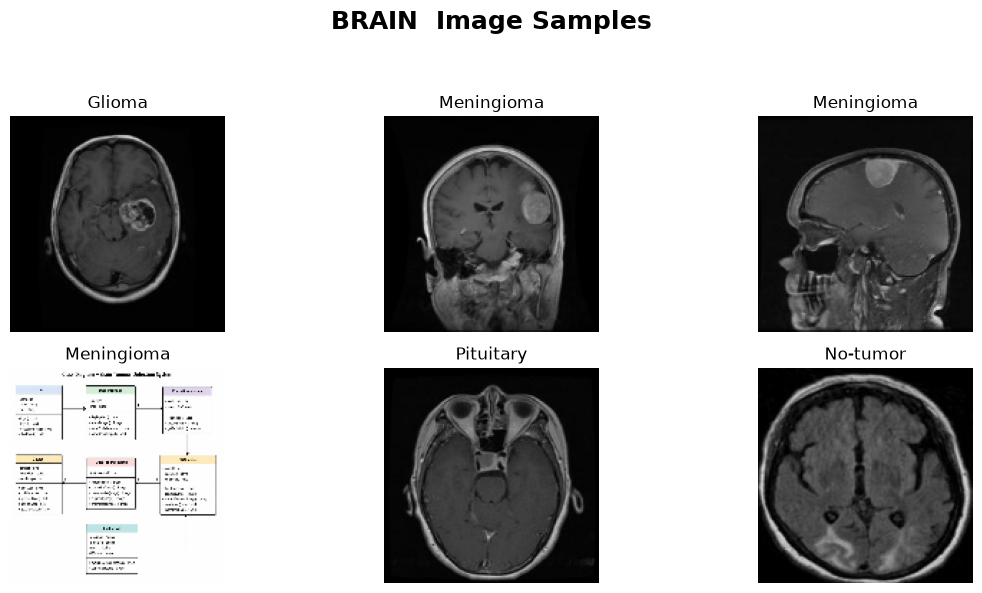

In [12]:
import matplotlib.pyplot as plt

index_to_class = {v: k for k, v in brain_class_labels.items()}

def display_examples(images, labels):
    plt.figure(figsize=(12, 6))
    plt.suptitle("BRAIN  Image Samples", fontsize=18, fontweight="bold")

    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.title(index_to_class[labels[i]], fontsize=12)
        plt.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


display_examples(train_images, train_labels)


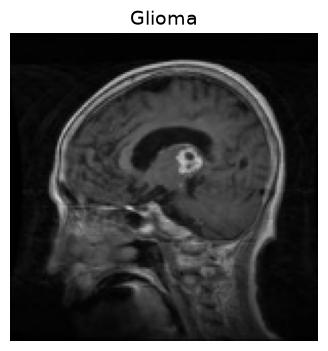

In [13]:
import matplotlib.pyplot as plt
import numpy as np

index_to_class = {v: k for k, v in brain_class_labels.items()}

def show_random_image(images, labels):
    idx = np.random.randint(len(images))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(images[idx])
    plt.title(f"{index_to_class[labels[idx]]}", fontsize=14)
    plt.axis("off")
    plt.show()


show_random_image(train_images, train_labels)


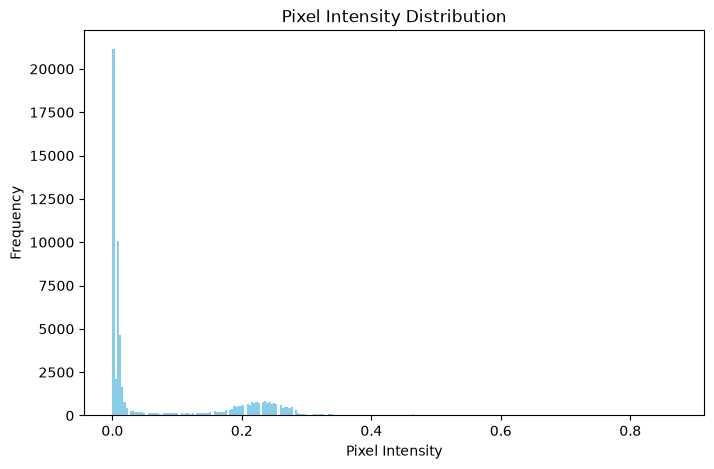

In [14]:
def plot_pixel_intensity_histogram(image):
    plt.figure(figsize=(8, 5))
    plt.hist(image.ravel(), bins=256, color='skyblue')
    plt.title('Pixel Intensity Distribution')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.show()


plot_pixel_intensity_histogram(train_images[0])


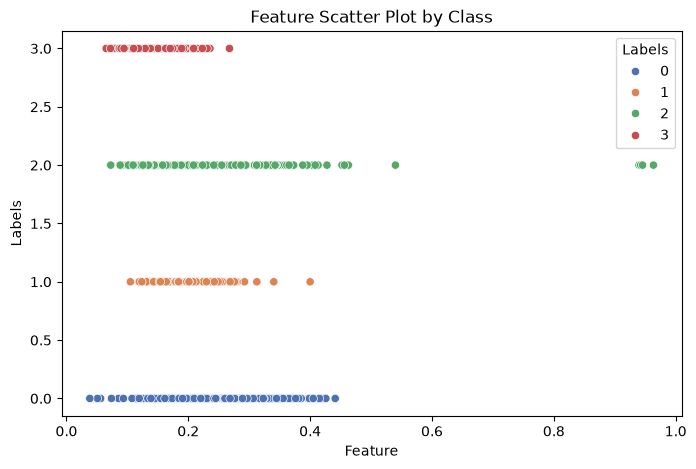

In [15]:
df = pd.DataFrame({'Labels': train_labels, 'Feature': [np.mean(img) for img in train_images]})
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Feature', y='Labels', hue='Labels', palette='deep')
plt.title('Feature Scatter Plot by Class')
plt.show()


C:\Users\aanil\AppData\Local\Temp\ipykernel_30444\1404880527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Labels', y='Feature', palette='muted')


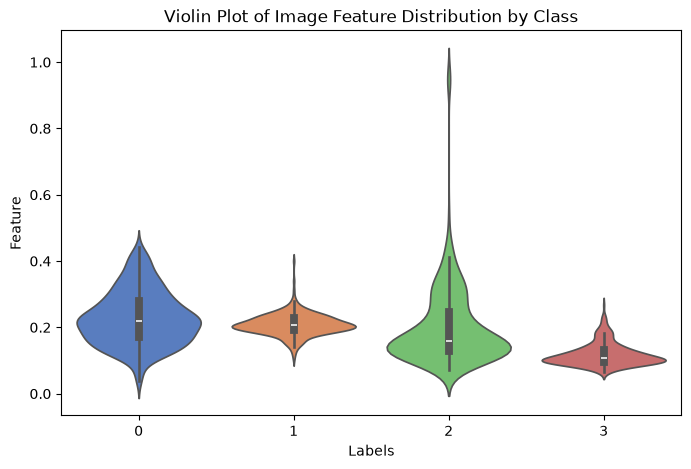

In [16]:
df = pd.DataFrame({'Labels': train_labels, 'Feature': [np.mean(img) for img in train_images]})
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Labels', y='Feature', palette='muted')
plt.title('Violin Plot of Image Feature Distribution by Class')
plt.show()


<Figure size 800x500 with 0 Axes>

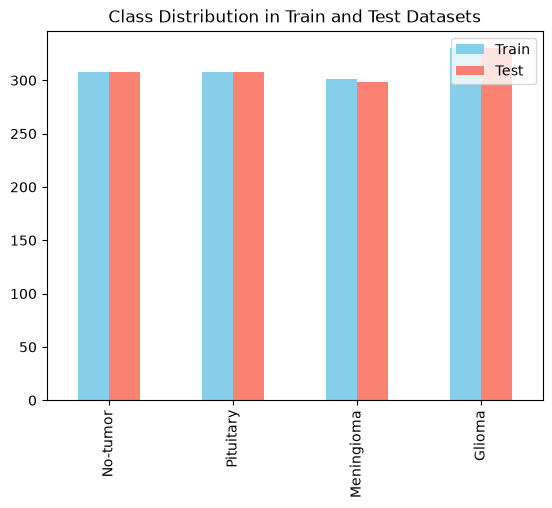

In [17]:

_, train_class_counts = np.unique(train_labels, return_counts=True)
_, test_class_counts = np.unique(test_labels, return_counts=True)


plt.figure(figsize=(8, 5))
pd.DataFrame({'Train': train_class_counts, 'Test': test_class_counts}, index=brain_class).plot.bar(color=['skyblue', 'salmon'])
plt.title('Class Distribution in Train and Test Datasets')
plt.show()


# MODEL

In [18]:
import tensorflow as tf


NUM_CLASSES = len(brain_class_labels)


model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(BRAIN_IMAGE_SIZE[0], BRAIN_IMAGE_SIZE[1], 3)
    ),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    batch_size=16,
    epochs=10,
    validation_split=0.2,
    shuffle=True
)


C:\Users\aanil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.5868 - loss: 1.0327 - val_accuracy: 0.7000 - val_loss: 0.7060
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - accuracy: 0.8074 - loss: 0.4750 - val_accuracy: 0.7720 - val_loss: 0.5779
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.9288 - loss: 0.2041 - val_accuracy: 0.8560 - val_loss: 0.5150
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.9619 - loss: 0.1119 - val_accuracy: 0.8120 - val_loss: 0.6827
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.9860 - loss: 0.0419 - val_accuracy: 0.7880 - val_loss: 0.7580
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.9829 - loss: 0.0496 - val_accuracy: 0.8760 - val_loss: 0.5994
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.8480 - val_loss: 0.7035
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accu

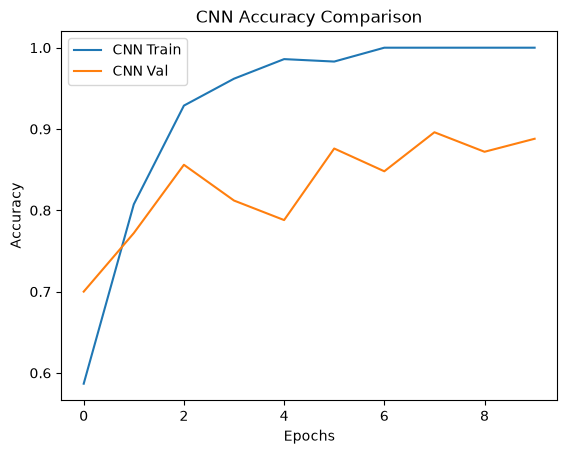

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy Comparison')
plt.legend(['CNN Train', 'CNN Val'])
plt.show()


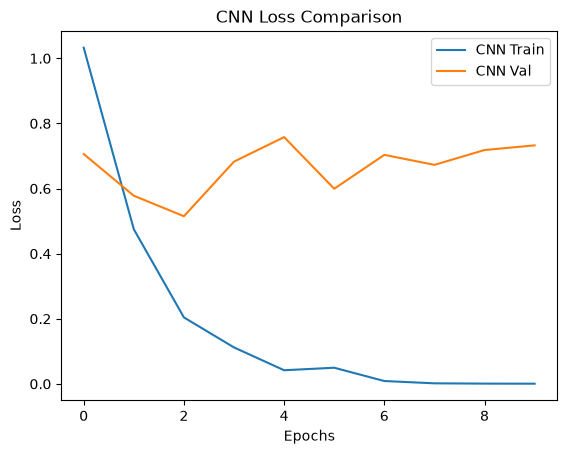

In [20]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss Comparison')
plt.legend(['CNN Train', 'CNN Val'])
plt.show()


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


y_pred_probs = model.predict(test_images)


y_pred = np.argmax(y_pred_probs, axis=1)


class_names = list(brain_class_labels.keys())


print("\n📊 Classification Report:\n")
print(
    classification_report(
        test_labels,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step

📊 Classification Report:

              precision    recall  f1-score   support

    No-tumor     0.9803    0.9708    0.9755       308
   Pituitary     0.9871    0.9968    0.9919       308
  Meningioma     0.9597    0.9597    0.9597       298
      Glioma     0.9818    0.9818    0.9818       330

    accuracy                         0.9775      1244
   macro avg     0.9773    0.9773    0.9773      1244
weighted avg     0.9775    0.9775    0.9775      1244



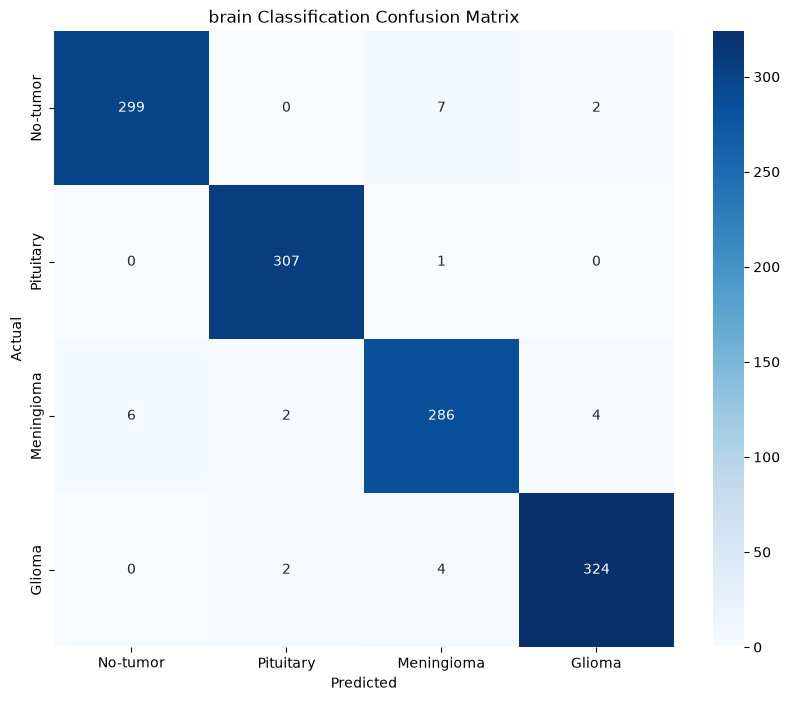

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("brain Classification Confusion Matrix")
plt.show()


In [23]:
model.save("brain.h5")
model_json = model.to_json()
with open("brain.json", "w") as json_file:
    json_file.write(model_json)

print("Model saved as 'brain.h5' and 'brain.json'.")


Model saved as 'brain.h5' and 'brain.json'.
